# Can an MLP learn the doubled-semion sign?

Pure supervised learning, no VMC and no energy: the arm-M network `m_θ(ε, x)` (tanh MLP, `N+F → h → h → 1`) is fitted to sign labels by weighted cross-entropy `Σ w·softplus(−y·m)` (full-batch Adam, lr 1e-2), and graded on held-out data.

**Input.** `σ → (ε, x)`: MWPM recovery bits `ε` (N of them) and hexagon-flip bits `x` (F of them). `(ε, x)` determines `σ`. In the topological phase the sign is, to 1e-6…1e-3 of the weight, a function of `x` alone: `(−1)^poly(x)`, the Levin–Gu cubic.

**Two splits of one dataset, 5-fold** (each configuration / each `x` pattern is held out exactly once; 80% train, 20% validation):

| split | held out | what it tests |
|---|---|---|
| `random` | configurations | memorisation: a held-out configuration shares its `x` pattern with training rows that differ only in `ε` |
| `pattern` | whole `x` patterns | generalisation: validation `x` patterns never occur in training |

**Reading the error panels.** `val` is the weighted sign error; `val (pattern-balanced)` gives every held-out `x` pattern equal weight, so one heavy pattern (`x = 0` at `h_z > 0`) cannot dominate. The honest baseline is not 50%: dotted grey = always answer the training-majority sign (in the same weighting as the balanced curve); dotted green = the computed head sign. Thin lines are folds, thick lines their mean.

Code: `scripts/sign_learn_split.py`, `jobs/nersc_signlearn.sh`; data: `results/signlearn/`.

In [1]:
import json, glob, os, pathlib
import numpy as np
import matplotlib.pyplot as plt

os.chdir(next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'results').is_dir()))
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
os.makedirs('figures/signlearn', exist_ok=True)
data = [json.load(open(f)) for f in sorted(glob.glob('results/signlearn/signlearn_*.json'))]
ed = sorted((d for d in data if d['source'] == 'ed'), key=lambda d: (d['hx'], d['hz']))
hd = sorted((d for d in data if d['source'] == 'head'), key=lambda d: d['F'])
name = lambda d: (f"({d['hx']:g}, {d['hz']:g})" if d['source'] == 'ed' else f"{d['Lx']}×{d['Ly']}  (F={d['F']}, N={d['N']})")
for d in data:
    print(name(d), f"n={d['n_data']}  MLP {d['N']+d['F']}→{d['hidden']}×{d['depth']}→1  steps={d['steps']}  fits={len(d['runs'])}", d['meta'])


def curves(ax, d, split, keys, refs=()):
    '''keys: (curve key, colour, label); refs: (run key, colour, label) drawn as flat fold-mean lines.'''
    runs = [r for r in d['runs'] if r['split'] == split]
    for key, c, lab in keys:
        a = np.array([r['curve'][key] for r in runs]); s = runs[0]['curve']['step']
        ax.plot(s, a.T, color=c, lw=0.6, alpha=0.3)
        ax.plot(s, a.mean(0), color=c, lw=1.8, label=lab)
    for key, c, lab in refs:
        ax.axhline(np.mean([r[key] for r in runs]), color=c, ls=':', lw=1.3, label=lab)
    ax.set_yscale('symlog', linthresh=1e-6); ax.set_xscale('symlog', linthresh=10); ax.grid(alpha=0.25)


LOSS = [('train_loss', 'C0', 'train loss'), ('val_loss', 'C1', 'validation loss')]
ERR = [('train_err', 'C0', 'train'), ('val_err', 'C1', 'val'), ('val_err_bal', 'C3', 'val (pattern-balanced)')]
REF = [('trainmajority_val_err_bal', 'grey', 'constant guess (balanced)'), ('head_val_err', 'C2', 'computed head sign')]


def figure(ds, split, title, fname, refs=REF):
    if not ds:
        return print(f'{fname}: no data yet (jobs still queued)')
    fig, axes = plt.subplots(2, len(ds), figsize=(4.3 * len(ds), 6.2), sharex=True, squeeze=False)
    for j, d in enumerate(ds):
        curves(axes[0, j], d, split, LOSS); curves(axes[1, j], d, split, ERR, refs)
        axes[0, j].set_title(name(d)); axes[1, j].set_xlabel('Adam step'); axes[1, j].set_ylim(-1e-7, 1.5)
    axes[0, 0].set_ylabel('cross-entropy loss'); axes[1, 0].set_ylabel('sign error')
    axes[0, 0].legend(fontsize=8); axes[1, 0].legend(fontsize=7.5, loc='lower left')
    fig.suptitle(title); fig.tight_layout(); fig.savefig(f'figures/signlearn/{fname}.png', dpi=150); plt.show()

3×3  (F=9, N=38) n=200000  MLP 47→128×2→1  steps=10000  fits=10 {'k_max': 18}
4×4  (F=16, N=63) n=200000  MLP 79→128×2→1  steps=10000  fits=10 {'k_max': 32}
5×5  (F=25, N=94) n=200000  MLP 119→128×2→1  steps=10000  fits=10 {'k_max': 50}
6×6  (F=36, N=131) n=200000  MLP 167→128×2→1  steps=10000  fits=10 {'k_max': 72}


## Figure 1 — 27 qubits (2×3), exact ED labels, three points in the topological phase

Dataset per point: the 200,000 configurations of largest `|ψ_ED|²` (distinct), labelled with the exact ground-state sign and weighted by `|ψ_ED|²`. 64 `x` patterns in total; the pattern split holds out 12–13 of them per fold.

In [2]:
figure(ed, 'random', 'Random 80/20 split over configurations (ED labels, 2×3)', 'fig1a_ed_random')

fig1a_ed_random: no data yet (jobs still queued)


In [3]:
figure(ed, 'pattern', 'Held-out x patterns, 80/20 over the 64 patterns (ED labels, 2×3)', 'fig1b_ed_pattern')

fig1b_ed_pattern: no data yet (jobs still queued)


### Held-out patterns, one by one

Every one of the 64 `x` patterns is held out in exactly one fold. A pattern counts as *correct* if the MLP's final weighted error inside it is below ½. The constant-guess column is what "always answer the majority sign of the 64 patterns" scores.

In [4]:
def tally(d):
    P = [(e, n) for r in d['runs'] if r['split'] == 'pattern' and 'val_patterns' in r
         for e, n in zip(r['val_patterns']['err'], r['val_patterns']['neg_share'])]
    e, n = np.array(P).T
    neg = n > 0.5
    return len(e), int((e < 0.5).sum()), int(max(neg.sum(), (~neg).sum())), int((e[neg] < 0.5).sum()), int(neg.sum()), int((e[~neg] < 0.5).sum()), int((~neg).sum())

print(f"{'dataset':26s} {'held-out patterns':>18s} {'MLP correct':>12s} {'constant guess':>15s} {'neg. patterns':>14s} {'pos. patterns':>14s}")
for d in ed + [h for h in hd if h['F'] <= 9]:
    if not any('val_patterns' in r for r in d['runs']): continue
    k, ok, const, okn, nn, okp, npos = tally(d)
    print(f"{name(d):26s} {k:18d} {ok:9d}/{k:<3d} {const:11d}/{k:<3d} {okn:9d}/{nn:<4d} {okp:9d}/{npos:<4d}")

dataset                     held-out patterns  MLP correct  constant guess  neg. patterns  pos. patterns
3×3  (F=9, N=38)                          512       384/512         328/512       269/328        115/184 


## Figure 2 — beyond ED: 3×3 to 6×6, labels from the closed-form head sign

No exact ground state exists at these sizes. The label is the head's sign (MWPM, then loop parity) — the exact ground-state sign on the `h_x = 0` line, and the function a learned sign layer would have to reproduce elsewhere. Configurations are synthetic: a uniformly random closed-loop set plus `k ≤ 2F` random link flips, 200,000 distinct, uniform weights. MLP width 128, 10,000 steps.

The number printed under each title is the share of **random-split** validation rows whose `x` pattern also occurs in training. Where it is ~100% (3×3, 4×4) the random split tests memorisation and the two splits differ; where it is ~0% (5×5, 6×6) every sample has its own pattern, the two splits are the same experiment, and agreement between them is not a separate finding.

3×3  (F=9, N=38)         distinct x patterns in data:     512 of 2^9;  random-split val rows with a seen pattern: 100.0%
4×4  (F=16, N=63)        distinct x patterns in data:   62472 of 2^16;  random-split val rows with a seen pattern: 91.3%
5×5  (F=25, N=94)        distinct x patterns in data:  199392 of 2^25;  random-split val rows with a seen pattern: 0.5%
6×6  (F=36, N=131)       distinct x patterns in data:  200000 of 2^36;  random-split val rows with a seen pattern: 0.0%


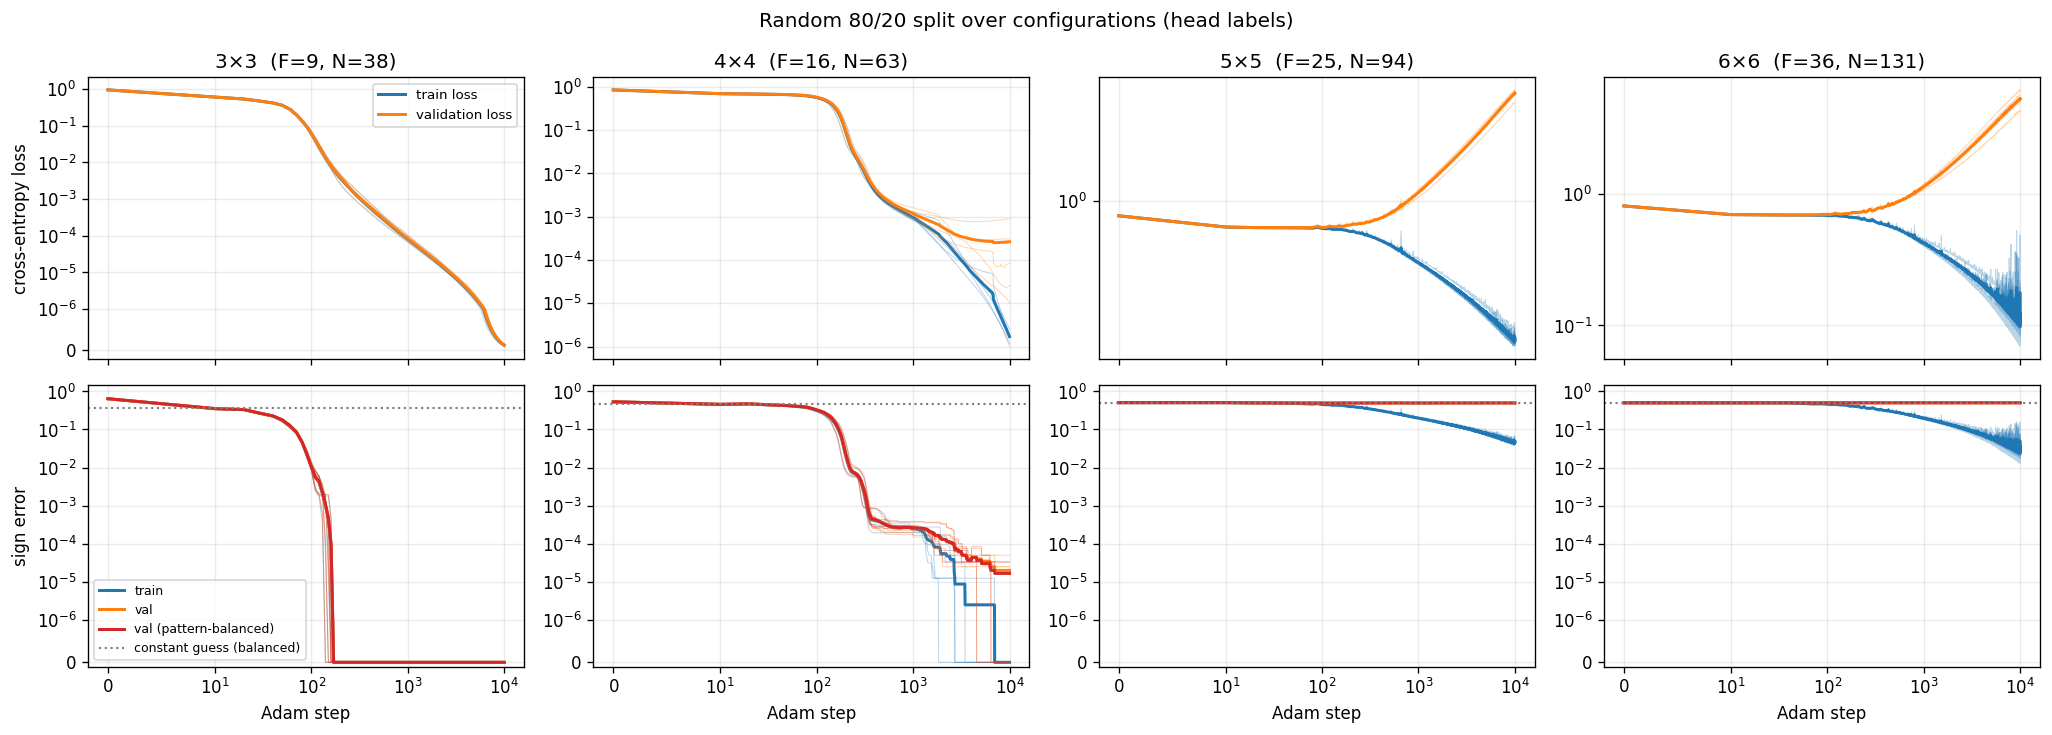

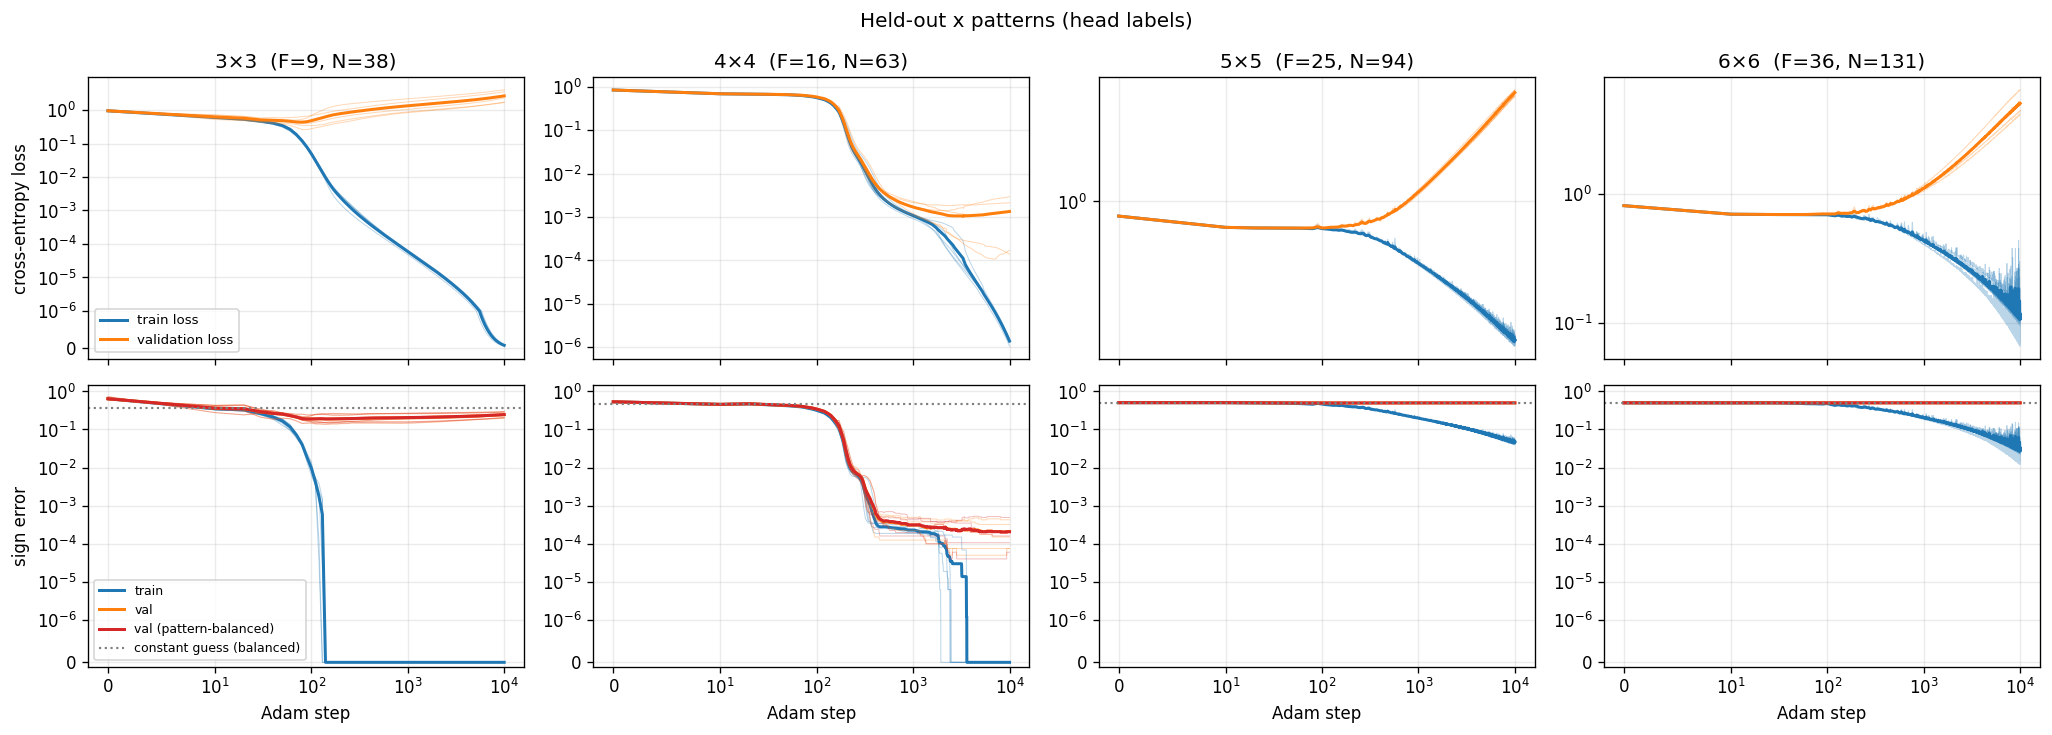

In [5]:
seen = lambda d: np.mean([r['val_rows_pattern_seen'] for r in d['runs'] if r['split'] == 'random'])
for d in hd:
    print(f"{name(d):24s} distinct x patterns in data: {d['runs'][0]['n_patterns']:7d} of 2^{d['F']};  random-split val rows with a seen pattern: {100 * seen(d):.1f}%")
HREF = [('trainmajority_val_err_bal', 'grey', 'constant guess (balanced)')]
figure(hd, 'random', 'Random 80/20 split over configurations (head labels)', 'fig2a_head_random', HREF)
figure(hd, 'pattern', 'Held-out x patterns (head labels)', 'fig2b_head_pattern', HREF)

## Summary — final errors against system size

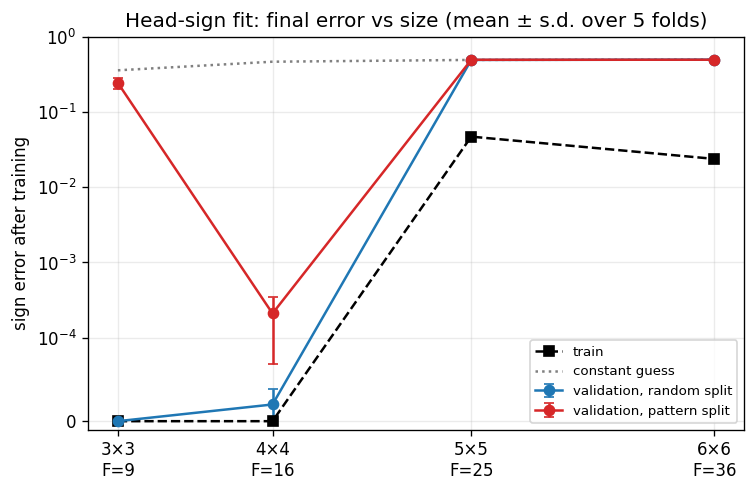

dataset                    split     train err    val err    val bal   best val  const (bal)      head
3×3  (F=9, N=38)           random     0.00e+00   0.00e+00   0.00e+00   0.00e+00     3.59e-01  0.00e+00
3×3  (F=9, N=38)           pattern    0.00e+00   2.44e-01   2.45e-01   1.77e-01     3.59e-01  0.00e+00
4×4  (F=16, N=63)          random     0.00e+00   2.00e-05   1.67e-05   2.00e-05     4.69e-01  0.00e+00
4×4  (F=16, N=63)          pattern    0.00e+00   2.10e-04   2.06e-04   1.90e-04     4.68e-01  0.00e+00
5×5  (F=25, N=94)          random     4.73e-02   4.95e-01   4.95e-01   4.88e-01     4.96e-01  0.00e+00
5×5  (F=25, N=94)          pattern    4.65e-02   4.98e-01   4.98e-01   4.91e-01     4.96e-01  0.00e+00
6×6  (F=36, N=131)         random     2.39e-02   5.00e-01   5.00e-01   4.95e-01     5.01e-01  0.00e+00
6×6  (F=36, N=131)         pattern    2.87e-02   4.99e-01   4.99e-01   4.96e-01     5.01e-01  0.00e+00


In [6]:
fin = lambda d, split, key: np.array([r['curve'][key][-1] for r in d['runs'] if r['split'] == split])
best = lambda d, split, key: np.array([min(r['curve'][key]) for r in d['runs'] if r['split'] == split])
fig, ax = plt.subplots(figsize=(6.4, 4.2))
F = [d['F'] for d in hd]
for split, c in (('random', 'C0'), ('pattern', 'C3')):
    m = [fin(d, split, 'val_err').mean() for d in hd]; s = [fin(d, split, 'val_err').std() for d in hd]
    ax.errorbar(F, m, yerr=s, color=c, marker='o', capsize=3, label=f'validation, {split} split')
ax.plot(F, [fin(d, 'random', 'train_err').mean() for d in hd], color='k', marker='s', ls='--', label='train')
ax.plot(F, [np.mean([r['trainmajority_val_err'] for r in d['runs']]) for d in hd], color='grey', ls=':', label='constant guess')
ax.set_yscale('symlog', linthresh=1e-4); ax.set_ylim(-1e-5, 1); ax.set_xticks(F, [f"{d['Lx']}×{d['Ly']}\nF={d['F']}" for d in hd])
ax.set_ylabel('sign error after training'); ax.grid(alpha=0.25); ax.legend(fontsize=8)
ax.set_title('Head-sign fit: final error vs size (mean ± s.d. over 5 folds)')
fig.tight_layout(); fig.savefig('figures/signlearn/fig3_error_vs_size.png', dpi=150); plt.show()

print(f"{'dataset':26s} {'split':8s} {'train err':>10s} {'val err':>10s} {'val bal':>10s} {'best val':>10s} {'const (bal)':>12s} {'head':>9s}")
for d in ed + hd:
    for split in ('random', 'pattern'):
        R = [r for r in d['runs'] if r['split'] == split]
        print(f"{name(d):26s} {split:8s} {fin(d, split, 'train_err').mean():10.2e} {fin(d, split, 'val_err').mean():10.2e} "
              f"{fin(d, split, 'val_err_bal').mean():10.2e} {best(d, split, 'val_err').mean():10.2e} "
              f"{np.mean([r['trainmajority_val_err_bal'] for r in R]):12.2e} {np.mean([r['head_val_err'] for r in R]):9.2e}")